#**📝Práctica: Clasificación de Ropa con Fashion MNIST**
**💡Consigna:**
- El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

##**🗂️1. Carga de Datos y Preprocesamiento**
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [1]:
import tensorflow as tf                      # Librería principal para crear redes neuronales.
from tensorflow.keras import layers, models  # Herramientas para armar las capas y agruparlas en un modelo.
import matplotlib.pyplot as plt              # Librería para crear gráficos.
import numpy as np                           # Librería para hacer cálculos matemáticos rápidos.

In [2]:
# Cargamos el dataset de ropa,
fashion_mnist = tf.keras.datasets.fashion_mnist                                       # Trae el catálogo de ropa.
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()  # Descarga las imágenes y las divide en dos grupos.

# Etiquetas de las 10 categorías (lista con los nombres de las prendas).
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# AYUDA: Dividir los arreglos por 255.0 para normalizar los píxeles al rango [0, 1].
train_images = train_images / 225.0  # Escala los colores de las imágenes de entrenamiento para que valgan entre 0 y 1.
test_images = test_images / 255.0    # Hace exactamente la misma normalización matemática con las imágenes de prueba.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##**✏️2. Definición de la Arquitectura (MLP)**
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [3]:
# Modelo secuencial, donde la información pasa por las capas una tras otra.
model = models.Sequential([

    # Capa de Entrada: Aplana la imagen de 28x28 a un vector de 784.
    layers.Flatten(input_shape=(28, 28)),

    # AYUDA: Agrega una capa densa con 128 neuronas y activación 'relu'
    layers.Dense(128, activation='relu'),
    # Capa oculta 1: tiene 128 neuronas. Usa ReLU para aprender rápido, dejando pasar solo señales positivas.

    # AYUDA: Agrega otra capa densa con 64 neuronas y activación 'relu'.
    layers.Dense(64, activation='relu'),
    # Capa oculta 2: tiene 64 neuronas. Sigue filtrando y destilando la información usando ReLU.

    # Capa de Salida: 10 neuronas para las 10 clases de ropa.
    # AYUDA: ¿Qué función de activación se usa para clasificación multiclase?.
    layers.Dense(10, activation='softmax')
    # Capa de salida: 10 neuronas (una para cada categoría de ropad.)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##**🔬3. Compilación y Entrenamiento**
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [4]:
model.compile(
    optimizer='adam',                        # El motor que ajusta los pesos (hace el descenso de gradiente).
    loss='sparse_categorical_crossentropy',  # La función de pérdida.
    metrics=['accuracy']                     # Guarda el procentaje de aciertos en cada paso.
)

# AYUDA: Implementar Early Stopping para monitorear 'val_loss' y evitar el sobreajuste.
# Esto detendrá el entrenamiento si el error de validación deja de mejorar.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # Vigila el error en los datos de validación.
    patience=5,                # Si se pasan 5 épocas seguidas el error no baja, frena el entrenamiento.
    restore_best_weights=True  # Cuando frena, cuelve atrás  y se queda con los pesos de la mejor época.
)

# Entrenamiento.
history = model.fit(
    train_images, train_labels,  # Se le pasan las imágenes y sus respuestas correctas para que aprenda.
    epochs=30,                   # Límite máximo: puede leer todos los datos hasta 30 veces.
    validation_split=0.2,        # Separa el 20% de los datos de entrenamiento para usarlos como validación.
    callbacks=[early_stop]       # Se indica la parada temprana.
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8186 - loss: 0.5074 - val_accuracy: 0.8464 - val_loss: 0.4244
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8617 - loss: 0.3765 - val_accuracy: 0.8618 - val_loss: 0.3763
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8749 - loss: 0.3406 - val_accuracy: 0.8650 - val_loss: 0.3649
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8826 - loss: 0.3159 - val_accuracy: 0.8643 - val_loss: 0.3746
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8896 - loss: 0.2974 - val_accuracy: 0.8787 - val_loss: 0.3356
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8962 - loss: 0.2804 - val_accuracy: 0.8833 - val_loss: 0.3358
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9000 - loss: 0.2683 - val_accuracy: 0.8829 - val_loss: 0.3277
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9039 - loss: 0.2576 -

##**🖥️4. Evaluación y Predicción**
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 3ms/step - accuracy: 0.8856 - loss: 0.3289

Precisión en el set de prueba: 88.56%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


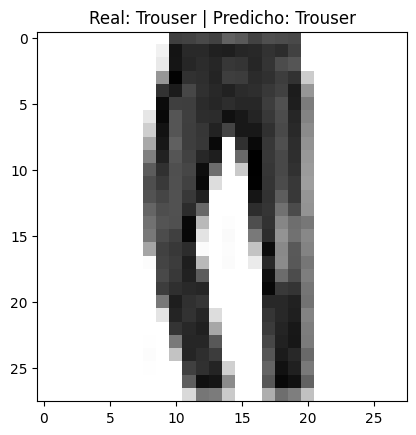

In [6]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')

# AYUDA: Realiza una predicción sobre el set de prueba.
predictions = model.predict(test_images)

# Visualización de una predicción individual.
n = 5  # Imagen de la lista a revisar.
plt.imshow(test_images[n], cmap=plt.cm.binary)
plt.title(f"Real: {class_names[test_labels[n]]} | Predicho: {class_names[np.argmax(predictions[n])]}")
plt.show()

##**📚Guía:**
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .